<div style="text-align:center;">

# 🚢 Titanic - Machine Learning From Disaster
## 📊 Dataset Cleaning & Visualization


</div>

In [ ]:
# Import required libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
# Display success message
display(HTML("""
<div style="
    background-color:#d4edda;
    color:#155724;
    border:2px solid #c3e6cb;
    border-radius:10px;
    padding:15px;
    font-size:18px;
    font-weight:bold;
    text-align:center;">
    ✅ Required libraries imported successfully!
</div>
"""))

In [ ]:
# Upload dataset from your computer
from google.colab import files
# Display upload instruction
display(HTML("""
<div style="
    background-color:#e8f4fd;
    color:#0c5460;
    border-left:6px solid #17a2b8;
    border-radius:8px;
    padding:15px;
    font-size:16px;">
    <h3 style="margin-top:0;">📂 Upload Titanic Dataset</h3>
    Please select the required dataset file(s) from your computer.
</div>
"""))
# Open upload dialog
uploaded = files.upload()
# Display success message
display(HTML(f"""
<div style="
    background-color:#d4edda;
    color:#155724;
    border-left:6px solid #28a745;
    border-radius:8px;
    padding:15px;
    font-size:16px;">
    ✅ <b>Upload Successful!</b><br>
    Uploaded file(s): <b>{', '.join(uploaded.keys())}</b>
</div>
"""))

Saving train.csv to train (1).csv


In [ ]:
# Load Titanic training dataset
df = pd.read_csv("train.csv")
# Display success message
display(HTML("""
<div style="
    background-color:#d4edda;
    color:#155724;
    border:2px solid #c3e6cb;
    border-radius:10px;
    padding:15px;
    font-size:18px;
    font-weight:bold;
    text-align:center;">
    ✅ Titanic dataset loaded successfully!
</div>
"""))

In [ ]:
# Missing value Analysis
missing_values = df.isnull().sum()
missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})
missing_df = missing_df[missing_df["Missing Values"] > 0]
display(HTML("""
<h2 style='color:#1f77b4;'>📌 Missing Value Analysis</h2>
"""))
display(
    missing_df.style
    .background_gradient(cmap="Reds")
    .set_properties(**{
        "text-align":"center",
        "padding":"8px"
    })
)

,Column,Missing Values
5,Age,177
10,Cabin,687
11,Embarked,2


In [ ]:
# Handle Missing Values
# Remove Cabin column
if "Cabin" in df.columns:
    df.drop("Cabin", axis=1, inplace=True)
# Fill Age missing values using median
df["Age"] = df["Age"].fillna(df["Age"].median())
# Fill Embarked missing values using mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
# Display success message
display(HTML("""
<div style="
background-color:#d4edda;
padding:15px;
border-radius:10px;
border-left:6px solid #28a745;
font-size:17px;
color:#155724;">
<b>✅ Missing Values Handled Successfully</b>
</div>
"""))
# Check remaining missing values
remaining_missing = pd.DataFrame({
    "Column": df.columns,
    "Remaining Missing Values": df.isnull().sum().values
})
display(HTML("""
<h3 style='color:#1f77b4;'>📌 Remaining Missing Values After Cleaning</h3>
"""))
display(
    remaining_missing.style
    .background_gradient(cmap="Greens")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px"
    })
)

,Column,Remaining Missing Values
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,0
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


## 📝 Missing Values Handling Summary

The Titanic dataset contained missing values in the **Age**, **Cabin**, and **Embarked** columns.

### Reasoning

- **Cabin:** The column was removed because most of its values were missing, making accurate replacement difficult and likely to introduce unreliable information.

- **Age:** Missing values were filled using the **median** because the median is less affected by outliers than the mean and provides a more robust estimate for numerical data.

- **Embarked:** Missing values were filled using the **mode** because it is a categorical feature, and replacing missing values with the most frequent category is an appropriate imputation method.

After applying these preprocessing steps, the dataset contained no remaining missing values in the retained columns and was ready for further analysis and visualization.

In [ ]:
# Identify numerical columns
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Numerical Columns</h2>"
))
numerical = pd.DataFrame({
    "Numerical Columns":
    df.select_dtypes(include=np.number).columns
})
numerical.style.background_gradient(cmap="Blues")

,Numerical Columns
0,PassengerId
1,Survived
2,Pclass
3,Age
4,SibSp
5,Parch
6,Fare


## 📝 Selection of Numerical Features for Outlier Detection

The Titanic dataset contains seven numerical columns. However, not all numerical columns are suitable for outlier analysis.

- **PassengerId** was excluded because it is a unique identifier assigned to each passenger and does not represent a measurable characteristic. Therefore, outlier detection is not meaningful for this column.
- **Survived** was excluded because it is the target variable with only two possible values (0 = Did Not Survive, 1 = Survived). Since it is a binary categorical variable encoded as numbers, outlier detection is not applicable.

Outlier analysis was therefore performed only on the following numerical features:
- **Pclass**
- **Age**
- **SibSp**
- **Parch**
- **Fare**

These features contain meaningful numerical values that can be analyzed for unusual observations using boxplots.

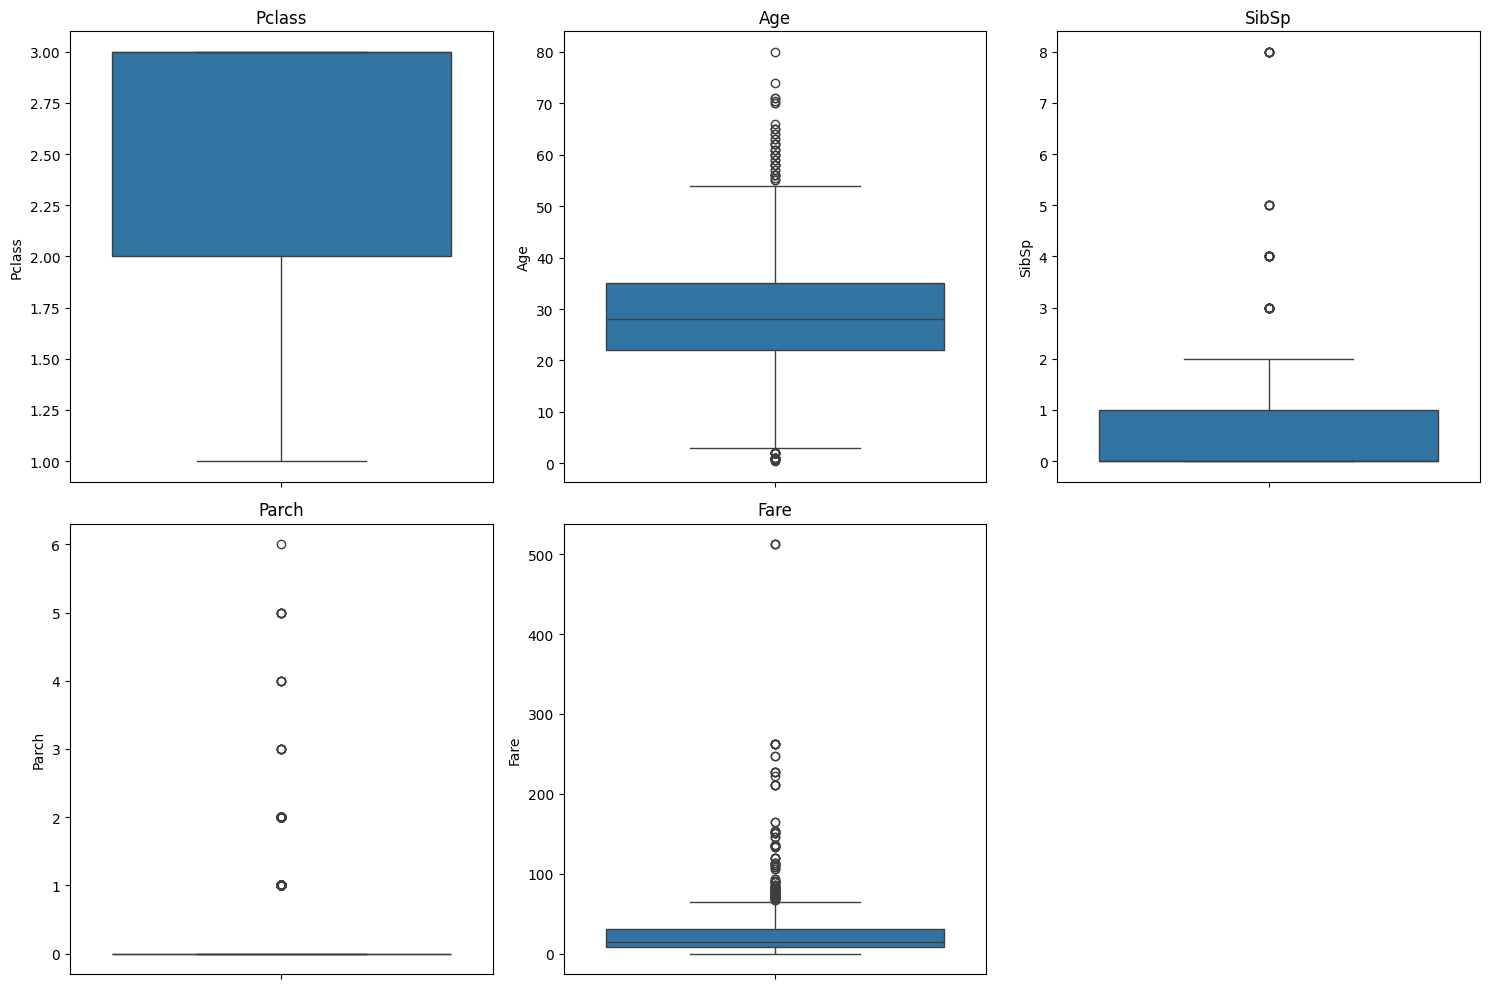

In [ ]:
# Detect Outliers in Numerical Features
display(HTML("""
<h2 style="color:#1f77b4;">
📌 Outlier Detection Using Boxplots
</h2>
"""))
# Numerical columns to analyze
numerical_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f"{column}")

plt.tight_layout()
plt.show()

## 📝 Outlier Detection Findings

Boxplots were used to detect potential outliers in the numerical features of the Titanic dataset. The observations are as follows:

- **Pclass:** No significant outliers were observed because this feature represents passenger classes (1, 2, and 3) rather than continuous numerical values.
- **Age:** A small number of outliers are present at both the lower and upper ends of the distribution, representing very young children and elderly passengers.
- **SibSp:** A few outliers were identified, indicating that some passengers traveled with an unusually large number of siblings or spouses.
- **Parch:** Some outliers are present, showing that a small number of passengers traveled with many parents or children.
- **Fare:** This feature contains the highest number of outliers. A few passengers paid exceptionally high fares compared to the majority, most likely representing first-class passengers rather than data entry errors.



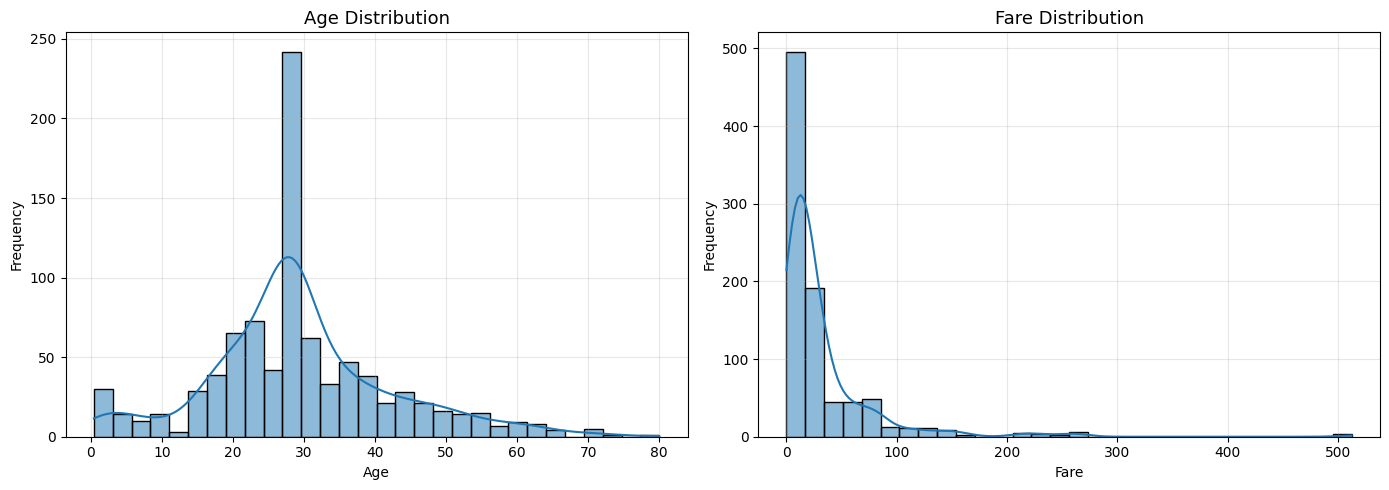

In [ ]:
# Histograms for Age and Fare
display(HTML("""
<h2 style="color:#1f77b4;">
📊 Histograms of Age and Fare
</h2>
"""))
hist_columns = ["Age", "Fare"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, column in enumerate(hist_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"{column} Distribution", fontsize=13)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observation: Age and Fare Distribution

The histograms provide insights into the distribution patterns of the numerical features **Age** and **Fare**.

### 👤 Age Distribution
- The **Age** feature shows the range of passenger ages in the dataset.
- Most passengers were within the young to middle-aged groups, with fewer elderly passengers.
- The distribution helps identify common age groups and understand the demographic structure of Titanic passengers.

### 💰 Fare Distribution
- The **Fare** feature shows a **right-skewed distribution**.
- Most passengers paid relatively lower fares, while a small number of passengers paid significantly higher fares.
- The presence of high fare values indicates differences in passenger class and ticket categories.

### Overall Insight
- Age and Fare distributions help identify passenger characteristics and possible patterns that may contribute to survival differences.
- Fare variation is especially useful because it is related to passenger class, which had an impact on survival.

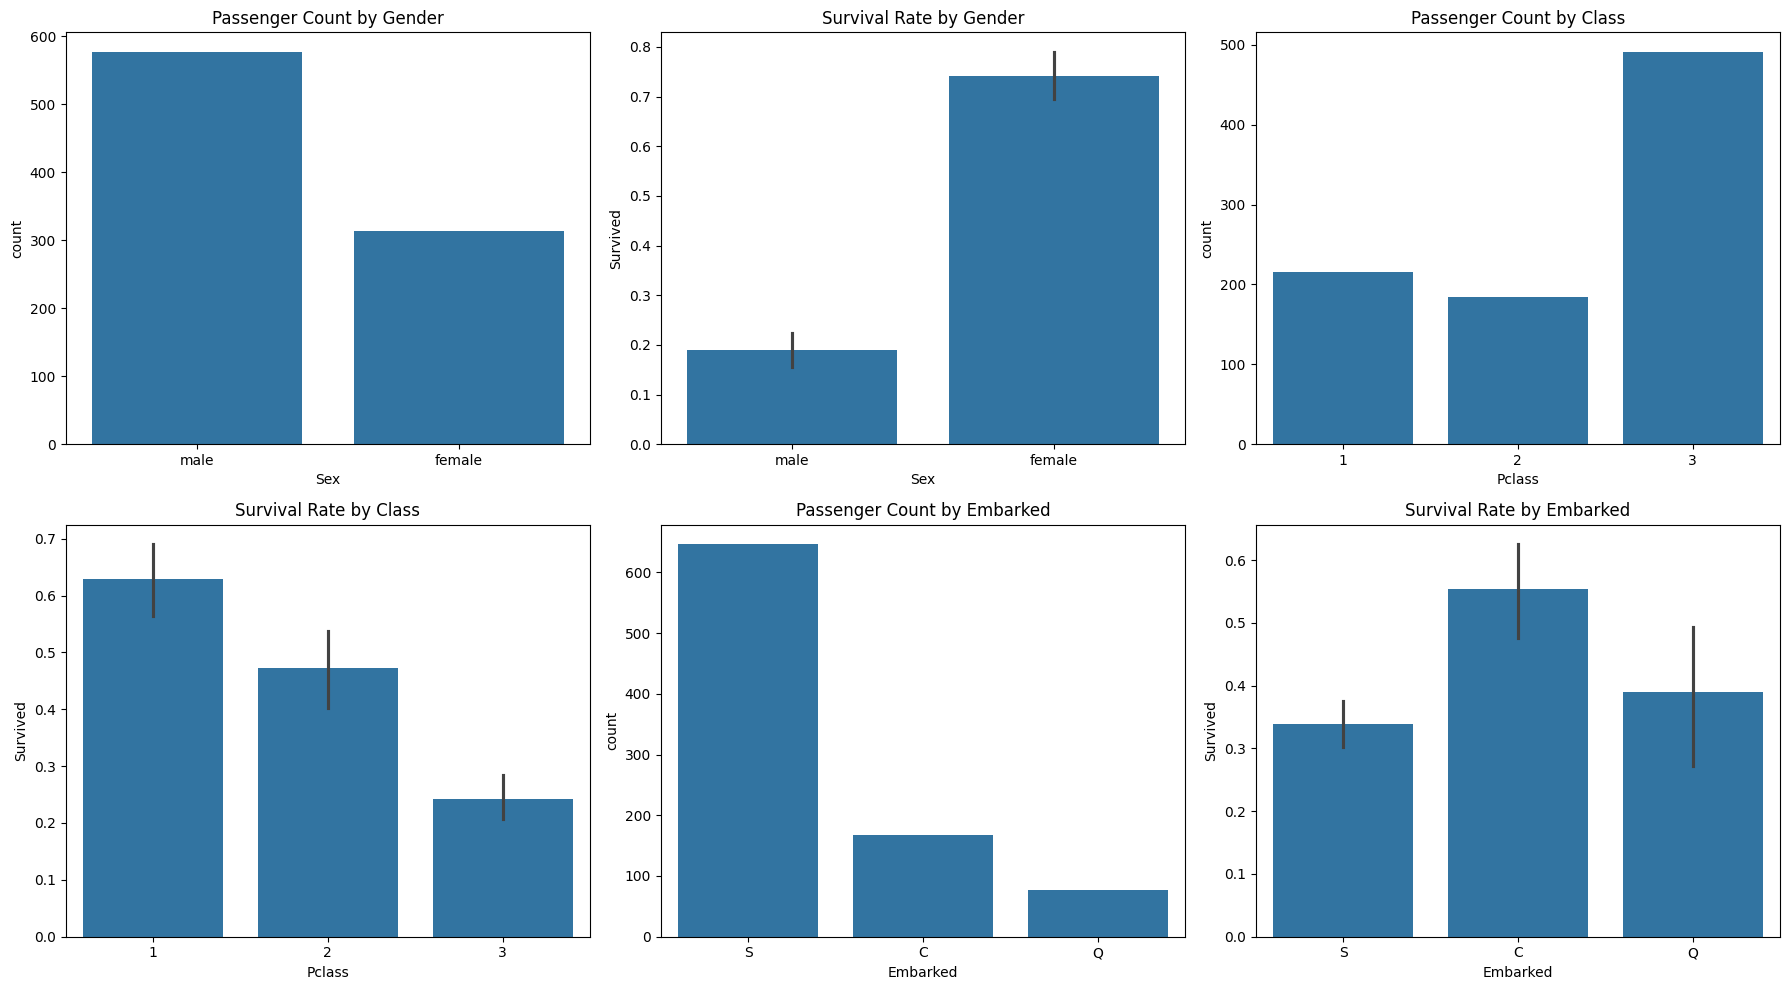

In [ ]:
# Bar Charts for all meaningful categorical analyses
display(HTML("""
<h2 style="color:#1f77b4;">
📊 Bar Charts of Categorical Features
</h2>
"""))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Passenger Count by Gender
sns.countplot(data=df, x="Sex", ax=axes[0,0])
axes[0,0].set_title("Passenger Count by Gender")
# Survival Rate by Gender
sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Gender")
# Passenger Count by Class
sns.countplot(data=df, x="Pclass", ax=axes[0,2])
axes[0,2].set_title("Passenger Count by Class")
# Survival Rate by Class
sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1,0])
axes[1,0].set_title("Survival Rate by Class")
# Passenger Count by Embarked
sns.countplot(data=df, x="Embarked", ax=axes[1,1])
axes[1,1].set_title("Passenger Count by Embarked")
# Survival Rate by Embarked
sns.barplot(data=df, x="Embarked", y="Survived", ax=axes[1,2])
axes[1,2].set_title("Survival Rate by Embarked")
plt.tight_layout()
plt.show()

## Observation: Categorical Features Analysis

The bar charts illustrate the distribution of passengers and the relationship between categorical features and survival rates.

### 👥 Sex Analysis
- The dataset contains a higher number of **male passengers** compared to female passengers.
- Despite being fewer in number, **female passengers had a significantly higher survival rate** than male passengers.
- This indicates that **Sex was one of the strongest factors associated with survival**.

### 🎫 Passenger Class (Pclass) Analysis
- The majority of passengers belonged to **Third Class**, while **First Class** had the fewest passengers.
- First-class passengers showed a higher survival rate compared to Second and Third Class passengers.
- This suggests that passenger class influenced survival chances, possibly due to differences in facilities and access to lifeboats.

### 🚢 Embarked Analysis
- Most passengers boarded from **Southampton (S)**, followed by **Cherbourg (C)** and **Queenstown (Q)**.
- Survival rates varied among different embarkation points, but the difference was smaller compared to the impact of **Sex** and **Pclass**.
- Therefore, Embarked appears to have a weaker relationship with survival.

### Overall Insight
- Among the analyzed categorical features, **Sex showed the strongest association with survival**, while **Pclass also played an important role**.
- Embarked had some variation in survival rates but appeared to have a comparatively lower impact.

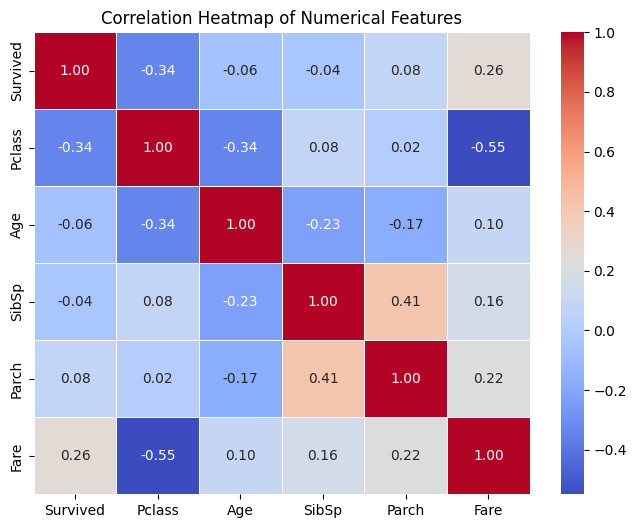

In [ ]:
# Correlation Heatmap of numerical features
corr_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Observation: Correlation Heatmap of Numerical Features

The correlation heatmap shows the linear relationship between numerical features and the target variable **Survived**.

### 🎫 Passenger Class (Pclass)
- **Pclass** has a negative correlation with survival.
- Since lower class numbers represent higher passenger classes (1st class), this indicates that passengers from higher classes had better survival chances.
- This suggests that passenger class was an important factor influencing survival.

### 💰 Fare Analysis
- **Fare** shows a positive correlation with survival.
- Passengers who paid higher fares generally had higher survival rates.
- This relationship is likely connected to passenger class, as higher fares were often associated with better accommodation and resources.

### 👤 Age Analysis
- **Age** shows a weak correlation with survival.
- This indicates that age alone does not have a strong linear relationship with survival.
- Although children may have had better survival chances, the overall effect of age was limited.

### 👨‍👩‍👧 Family Features (SibSp and Parch)
- **SibSp** and **Parch** show weak correlations with survival.
- The number of siblings, spouses, parents, or children aboard had a limited linear relationship with survival.
- These features alone were not strong indicators of survival.

### Overall Insight
- Among numerical features, **Pclass and Fare show the strongest relationship with survival**.
- However, the correlation values are moderate, indicating that numerical features alone do not fully explain survival patterns.
- Categorical analysis, especially **Sex vs Survival**, shows a stronger difference in survival rates compared to numerical features.

## Conclusion: Feature Affecting Survival the Most

Based on the EDA analysis, **Sex appears to be the feature that most affects survival in the Titanic dataset.**

The survival rate bar chart shows a **very large difference between male and female passengers**. Female passengers had a significantly higher survival rate compared to male passengers, indicating a strong association between gender and survival.

Although numerical features were also analyzed, they showed weaker relationships:

### 💰 Fare
- Fare had a positive relationship with survival, but it does not directly determine survival.
- Higher fares mainly represent passengers who belonged to higher classes, making it an indirect indicator of survival chances.

### 🎫 Pclass
- Passenger class showed a noticeable relationship with survival because first-class passengers had higher survival rates.
- However, the difference between classes was smaller compared to the survival gap between males and females.

### 👤 Age
- Age showed only a weak correlation with survival, meaning age alone was not a strong predictor.
- Although children had better survival chances, the overall effect across all ages was limited.

### 👨‍👩‍👧 SibSp and Parch
- These family-related features showed weak correlations with survival.
- The number of family members aboard had less influence on survival.

### Overall Conclusion
Therefore, **Sex was selected as the feature with the strongest impact because it showed the largest difference in survival rates compared to other features.** Numerical features such as **Fare** and **Pclass** contributed to survival patterns, but their effects were comparatively weaker and often related to other factors.